## Environment setup

### Configure your API keys

To pull Segment Anything 3 weights, you need a HuggingFace Access Token with approved access to the SAM 3 checkpoints.

- Request access to the SAM 3 checkpoints on the official Hugging Face [repo](https://github.com/facebookresearch/sam3).
- Open your HuggingFace Settings page. Click Access Tokens then New Token to generate a new token.
- In Colab, go to the left pane and click on Secrets (🔑). Store your HuggingFace Access Token under the name `HF_TOKEN`.








In [ ]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Thu Jun  4 00:57:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


### Install SAM 3 and extra dependencies

In [ ]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"
%cd /content

fatal: destination path 'sam3' already exists and is not an empty directory.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15717 sha256=f4aadc71f4bf07b94d792d1cdf9cadf4c3f9bb7bd71d3342a487c2e6393d5bb8
  Stored in directory: /tmp/pip-ephem-wheel-cache-infg3ptp/wheels/7c/90/be/80339bb9db8655024d6c9501da4e5efc6abbda4c897f5a6c43
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0
/content


In [ ]:
!pip install -q supervision jupyter_bbox_widget

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.7 MB/s eta 0:00:00


### Download example data

Downloads example images. You can use these or replace them with your own images.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**<font color="red">⚠️ Restart session before running cells below.</font>**








In [ ]:
!pip install -q open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 88.3 MB/s eta 0:00:00


In [ ]:
import open3d as o3d
import numpy as np

file_path = '/content/drive/MyDrive/ONESTRUCTION/2brup10-2_otc.ply'
pcd = o3d.io.read_point_cloud(file_path)
points = np.asarray(pcd.points)

print("--- 3D MODEL CALIBRATION DATA ---")
print(f"X-Axis: Min = {np.min(points[:, 0]):.2f}, Max = {np.max(points[:, 0]):.2f}, Range = {np.ptp(points[:, 0]):.2f}")
print(f"Y-Axis: Min = {np.min(points[:, 1]):.2f}, Max = {np.max(points[:, 1]):.2f}, Range = {np.ptp(points[:, 1]):.2f}")
print(f"Z-Axis (Height): Min = {np.min(points[:, 2]):.2f}, Max = {np.max(points[:, 2]):.2f}, Range = {np.ptp(points[:, 2]):.2f}")

--- 3D MODEL CALIBRATION DATA ---
X-Axis: Min = -139.69, Max = 8707.52, Range = 8847.22
Y-Axis: Min = 3611.32, Max = 11033.33, Range = 7422.00
Z-Axis (Height): Min = -76.46, Max = 2521.62, Range = 2598.08


Loading point cloud from: /content/drive/MyDrive/ONESTRUCTION/2brup10-2_otc.ply
Original point count: 6598974
Downsampling point cloud...
Downsampled point count: 514497
Removing statistical outliers...
Points remaining for the walls after slicing: 136563
Allocating 2D image grid: 294 x 248 pixels
Occupancy image successfully generated! Preview:


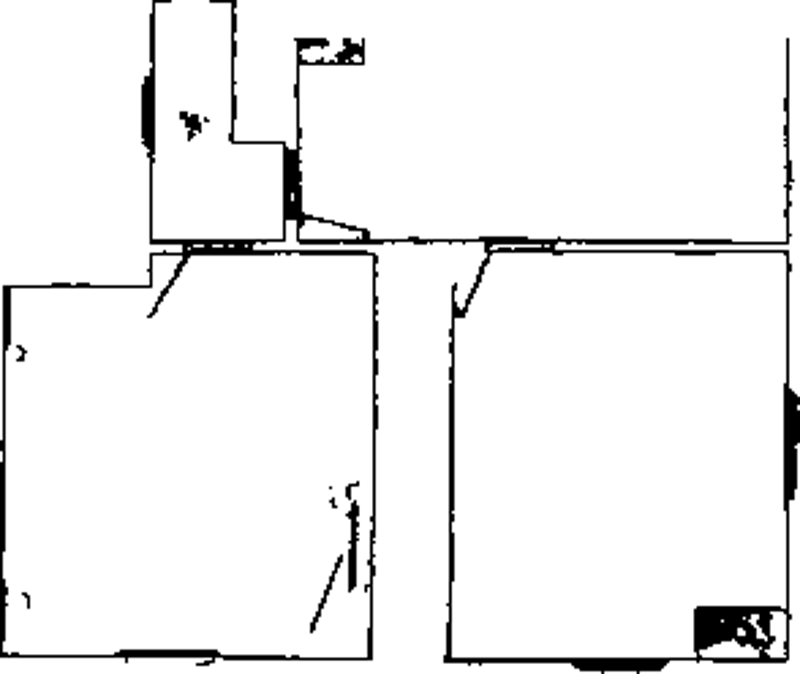

In [ ]:
import open3d as o3d
import numpy as np
from PIL import Image
from IPython.display import display

# 1. Load the Point Cloud
file_path = '/content/drive/MyDrive/ONESTRUCTION/2brup10-2_otc.ply'
print(f"Loading point cloud from: {file_path}")
pcd = o3d.io.read_point_cloud(file_path)
print(f"Original point count: {len(pcd.points)}")

# --- MITIGATION 1: Voxel Downsampling (MILLIMETER SCALE) ---
# We want 2cm cubes. In millimeters, 2cm = 20.
print("Downsampling point cloud...")
pcd = pcd.voxel_down_sample(voxel_size=20)
print(f"Downsampled point count: {len(pcd.points)}")

# --- MITIGATION 2: Outlier Removal ---
print("Removing statistical outliers...")
pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# Safe to move to NumPy
points = np.asarray(pcd.points)

# 2. Horizontal Slicing (MILLIMETER SCALE)
# The floor is at ~0. We want to take a clean slice between 1.0m and 1.5m
# high (chest level) to avoid furniture and ceiling fixtures.
# 1.0m = 1000mm, 1.5m = 1500mm
z_min = 1200
z_max = 2200
sliced_points = points[(points[:, 2] > z_min) & (points[:, 2] < z_max)]
print(f"Points remaining for the walls after slicing: {len(sliced_points)}")

# 3. Rasterization (MILLIMETER SCALE)
# We want 1 pixel to represent 3cm. In millimeters, 3cm = 30.
pixel_size = 30

x = sliced_points[:, 0]
y = sliced_points[:, 1]

x_shifted = x - np.min(x)
y_shifted = y - np.min(y)

x_pixels = (x_shifted / pixel_size).astype(int)
y_pixels = (y_shifted / pixel_size).astype(int)

# Determine the final image dimensions
width = np.max(x_pixels) + 1
height = np.max(y_pixels) + 1
print(f"Allocating 2D image grid: {width} x {height} pixels")

# --- MEMORY FAIL-SAFE ---
if (width * height) > 150000000:
    raise MemoryError("Grid is still too massive. Increase 'pixel_size' to 50 or higher.")

# Create the blank white image and paint the black walls
occupancy_grid = np.full((height, width), 255, dtype=np.uint8)
occupancy_grid[y_pixels, x_pixels] = 0

# 4. Save and Display the Image
occupancy_image = Image.fromarray(occupancy_grid)
occupancy_image.save('/content/occupancy_image.png')

print("Occupancy image successfully generated! Preview:")
display_width = 800
display_height = int(800 * (height / width))
display(occupancy_image.resize((display_width, display_height)))

In [ ]:
import scipy.ndimage as ndimage
import numpy as np
import open3d as o3d
from PIL import Image

# 1. Load the clean multi-room occupancy image
IMAGE_PATH = '/content/occupancy_image.png'
gray_image = np.array(Image.open(IMAGE_PATH).convert("L"))

# 2. Map the valid rooms
labeled_blobs, num_features = ndimage.label(gray_image == 255)
blob_sizes = np.bincount(labeled_blobs.flat)
blob_sizes[0] = 0
MIN_ROOM_PIXELS = 1000
valid_room_ids = np.where(blob_sizes > MIN_ROOM_PIXELS)[0]
print(f"Detected {len(valid_room_ids)} distinct rooms in the building scan!")

# 3. Align the FULL 3D point cloud with the 2D grid
# We use 'points' (the raw data), not 'sliced_points'
all_x = points[:, 0]
all_y = points[:, 1]
min_x = np.min(sliced_points[:, 0])
min_y = np.min(sliced_points[:, 1])

full_x_pixels = ((all_x - min_x) / 30).astype(int)
full_y_pixels = ((all_y - min_y) / 30).astype(int)

full_x_pixels = np.clip(full_x_pixels, 0, gray_image.shape[1] - 1)
full_y_pixels = np.clip(full_y_pixels, 0, gray_image.shape[0] - 1)

# 4. Extract ONLY the 3D walls (The Ring Method)
for i, room_id in enumerate(valid_room_ids):
    print(f"Processing Room {i+1} walls...")

    room_mask_2d = (labeled_blobs == room_id)

    # Create the "Cookie Cutter" ring
    outer_bound = ndimage.binary_dilation(room_mask_2d, iterations=8)
    inner_bound = ndimage.binary_erosion(room_mask_2d, iterations=2)
    wall_ring_mask = outer_bound ^ inner_bound

    # Drop the ring through the FULL point cloud
    belongs_to_wall = wall_ring_mask[full_y_pixels, full_x_pixels]
    room_wall_points = points[belongs_to_wall]

    # Export
    room_pcd = o3d.geometry.PointCloud()
    room_pcd.points = o3d.utility.Vector3dVector(room_wall_points)

    output_path = f'/content/drive/MyDrive/ONESTRUCTION/room_{i+1}_walls.ply'
    o3d.io.write_point_cloud(output_path, room_pcd)
    print(f"  -> Saved {len(room_wall_points)} floor-to-ceiling wall points.")

print("Phase 2 Complete: Floor-to-ceiling walls exported.")

Detected 6 distinct rooms in the building scan!
Processing Room 1 walls...
  -> Saved 54520 floor-to-ceiling wall points.
Processing Room 2 walls...
  -> Saved 64575 floor-to-ceiling wall points.
Processing Room 3 walls...
  -> Saved 118646 floor-to-ceiling wall points.
Processing Room 4 walls...
  -> Saved 129803 floor-to-ceiling wall points.
Processing Room 5 walls...
  -> Saved 115852 floor-to-ceiling wall points.
Processing Room 6 walls...
  -> Saved 110203 floor-to-ceiling wall points.
Phase 2 Complete: Floor-to-ceiling walls exported.


## Load SAM3 Image Predictor

On Ampere GPUs (compute capability ≥ 8), we enable TensorFloat-32 (TF32) for matrix multiplications and convolutions. This allows PyTorch to use tensor cores to accelerate FP32 computations while maintaining similar numerical accuracy.

In [ ]:
import torch

torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

In [ ]:
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

model = build_sam3_image_model(bpe_path="/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz")
processor = Sam3Processor(model, confidence_threshold=0.3)

/content/sam3/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

## Few utils to parse and visualize the result

In [ ]:
import supervision as sv

def from_sam(sam_result: dict) -> sv.Detections:
    xyxy = sam_result["boxes"].to(torch.float32).cpu().numpy()
    confidence = sam_result["scores"].to(torch.float32).cpu().numpy()

    mask = sam_result["masks"].to(torch.bool)
    mask = mask.reshape(mask.shape[0], mask.shape[2], mask.shape[3]).cpu().numpy()

    return sv.Detections(
        xyxy=xyxy,
        confidence=confidence,
        mask=mask
    )

In [ ]:
import supervision as sv
from PIL import Image
from typing import Optional


COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])


def annotate(image: Image.Image, detections: sv.Detections, label: Optional[str] = None) -> Image.Image:
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    mask_annotator = sv.MaskAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        opacity=0.6
    )
    box_annotator = sv.BoxAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        thickness=1
    )
    label_annotator = sv.LabelAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        text_scale=0.4,
        text_padding=5,
        text_color=sv.Color.BLACK,
        text_thickness=1
    )

    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)
    annotated_image = box_annotator.annotate(annotated_image, detections)

    if label:
        labels = [
            f"{label} {confidence:.2f}"
            for confidence in detections.confidence
        ]
        annotated_image = label_annotator.annotate(annotated_image, detections, labels)

    return annotated_image

In [ ]:
print([method for method in dir(processor) if 'prompt' in method.lower() or 'point' in method.lower()])

['add_geometric_prompt', 'reset_all_prompts', 'set_text_prompt']


## SAM 3 text prompt

In [ ]:
import inspect
print(inspect.signature(processor.add_geometric_prompt))

(box: List, label: bool, state: Dict)


Room Bounding Box: [X_min: 0, Y_min: 0, X_max: 276, Y_max: 429]
Detected 1 boundaries from the full box prompt.


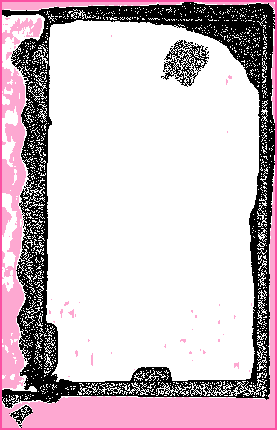

In [ ]:
import numpy as np
import supervision as sv
from PIL import Image
from IPython.display import display

# 1. Load the occupancy image you generated in Phase 1
IMAGE_PATH = '/content/occupancy_image.png'
image = Image.open(IMAGE_PATH).convert("RGB")

# 2. Find the bounding box of the ENTIRE room
# Convert to grayscale NumPy array to find the white pixels (255)
gray_image = np.array(image.convert("L"))
white_y, white_x = np.where(gray_image == 255)

# Calculate the extreme edges of the white floor space
x_min = int(np.min(white_x))
x_max = int(np.max(white_x))
y_min = int(np.min(white_y))
y_max = int(np.max(white_y))

print(f"Room Bounding Box: [X_min: {x_min}, Y_min: {y_min}, X_max: {x_max}, Y_max: {y_max}]")

# 3. Format the Box Prompt
# Pass the absolute pixel boundaries. SAM will segment the shape contained inside.
input_box = [x_min, y_min, x_max, y_max]
input_label = True

# 4. Run Inference
inference_state = processor.set_image(image)

state = processor.add_geometric_prompt(
    state=inference_state,
    box=input_box,
    label=input_label
)

# 5. Extract and Visualize
detections = from_sam(sam_result=state)
detections = detections[detections.confidence > 0.5]

# --- THE FIX: Give the detection a default class_id so supervision can pick a color ---
detections.class_id = np.zeros(len(detections), dtype=int)

print(f"Detected {len(detections)} boundaries from the full box prompt.")

# Visualize the result (telling it to color by INDEX instead of CLASS)
scene = np.array(image).copy()
scene = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX).annotate(scene, detections)
scene = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX).annotate(scene, detections)
display(Image.fromarray(scene))

Room void successfully isolated!


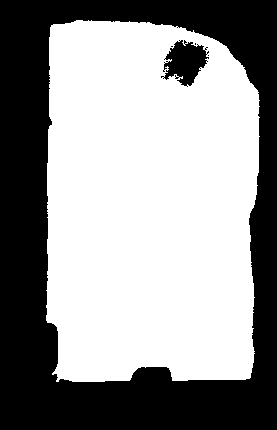

In [ ]:
import scipy.ndimage as ndimage
import numpy as np
from PIL import Image
from IPython.display import display

# 1. Load the grayscale occupancy image from Phase 1
IMAGE_PATH = '/content/occupancy_image.png'
gray_image = np.array(Image.open(IMAGE_PATH).convert("L"))

# 2. Find all distinct white blobs (clusters of 255 pixels)
# This maps every separate white puddle into its own indexed group
labeled_blobs, num_features = ndimage.label(gray_image == 255)

# 3. Find the largest blob (The Room)
# We count the pixels in each blob. [1:] ensures we ignore the black background.
largest_blob_id = np.argmax(np.bincount(labeled_blobs.flat)[1:]) + 1

# 4. Create the final mask (True for the room, False for everything else)
room_mask_2d = (labeled_blobs == largest_blob_id)
print("Room void successfully isolated!")

# 5. Visualize it to confirm!
# Multiplying by 255 turns the True/False mask into a visible White/Black image
display(Image.fromarray((room_mask_2d * 255).astype(np.uint8)))

In [ ]:
import open3d as o3d

# 1. Dilate the Mask
# We expand our clean 2D room mask outward by 8 pixels (8 cm) so it swallows the black wall lines.
expanded_mask_2d = ndimage.binary_dilation(room_mask_2d, iterations=8)

# 2. Back-Project to 3D
# We use the exact x_pixels and y_pixels arrays still saved in Colab's memory from Phase 1!
belongs_to_room = expanded_mask_2d[y_pixels, x_pixels]

# 3. Filter the 3D Points
room_3d_points = sliced_points[belongs_to_room]
print(f"Successfully isolated {len(room_3d_points)} 3D points for this room!")

# 4. Save the Segmented 3D Room for the next team
room_pcd = o3d.geometry.PointCloud()
room_pcd.points = o3d.utility.Vector3dVector(room_3d_points)

output_path = '/content/drive/MyDrive/ONESTRUCTION/segmented_room_1.xyz'
o3d.io.write_point_cloud(output_path, room_pcd)
print(f"Saved segmented 3D room to: {output_path}")

Successfully isolated 37641 3D points for this room!
Saved segmented 3D room to: /content/drive/MyDrive/ONESTRUCTION/segmented_room_1.xyz
